# Compare Stop Detection Algorithms

This notebook compares two stop-detection algorithms side by side on the same trajectory and parameters.

Supported algorithms: `dbstop`, `tadbscan`, `seqscan`.

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from shapely.geometry import box

import nomad.io.base as loader
import nomad.data as data_folder
from pathlib import Path

from nomad.stop_detection.viz import (
    plot_stops_barcode,
    plot_time_barcode,
    plot_stops,
    plot_pings,
)

import nomad.stop_detection.dbstop as DBSTOP
import nomad.stop_detection.dbscan as TADBSCAN
import nomad.stop_detection.density_based as SEQSCAN

# Choose the pair to compare
algo_a = 'dbstop'
algo_b = 'seqscan'

# Shared detection parameters
params = {
    'time_thresh': 60,
    'dist_thresh': 10,
    'min_pts': 3,
    'dur_min': 5,
}

if algo_a == algo_b:
    raise ValueError('Pick two different algorithms for comparison.')

supported = {'dbstop', 'tadbscan', 'seqscan'}
if algo_a not in supported or algo_b not in supported:
    raise ValueError(f'Algorithms must be in {supported}')

data_dir = Path(data_folder.__file__).parent
city = gpd.read_parquet(data_dir / 'garden-city-buildings-mercator.parquet')
outer_box = box(*city.total_bounds)

filepath_root = 'gc_data_long/'
tc = {'user_id': 'gc_identifier', 'x': 'dev_x', 'y': 'dev_y', 'timestamp': 'unix_ts'}

users = ['admiring_brattain']
traj = loader.sample_from_file(
    filepath_root,
    format='parquet',
    users=users,
    filters=('date', '==', '2024-01-01'),
    traj_cols=tc,
)

In [10]:
def run_algorithm(name, data, traj_cols, p):
    if name == 'dbstop':
        return DBSTOP.dbstop(
            data,
            time_thresh=p['time_thresh'],
            dist_thresh=p['dist_thresh'],
            min_pts=p['min_pts'],
            dur_min=p['dur_min'],
            complete_output=True,
            traj_cols=traj_cols,
        )

    if name == 'tadbscan':
        return TADBSCAN.ta_dbscan(
            data,
            time_thresh=p['time_thresh'],
            dist_thresh=p['dist_thresh'],
            min_pts=p['min_pts'],
            dur_min=p['dur_min'],
            complete_output=True,
            traj_cols=traj_cols,
        )

    if name == 'seqscan':
        return SEQSCAN.seqscan(
            data,
            time_thresh=p['time_thresh'],
            dist_thresh=p['dist_thresh'],
            min_pts=p['min_pts'],
            dur_min=p['dur_min'],
            complete_output=True,
            traj_cols=traj_cols,
        )

    raise ValueError(f'Unknown algorithm: {name}')

stops_a = run_algorithm(algo_a, traj, tc, params)
stops_b = run_algorithm(algo_b, traj, tc, params)

print(f'{algo_a}: n_stops = {len(stops_a)}')
print(f'{algo_b}: n_stops = {len(stops_b)}')

dbstop: n_stops = 3
seqscan: n_stops = 4


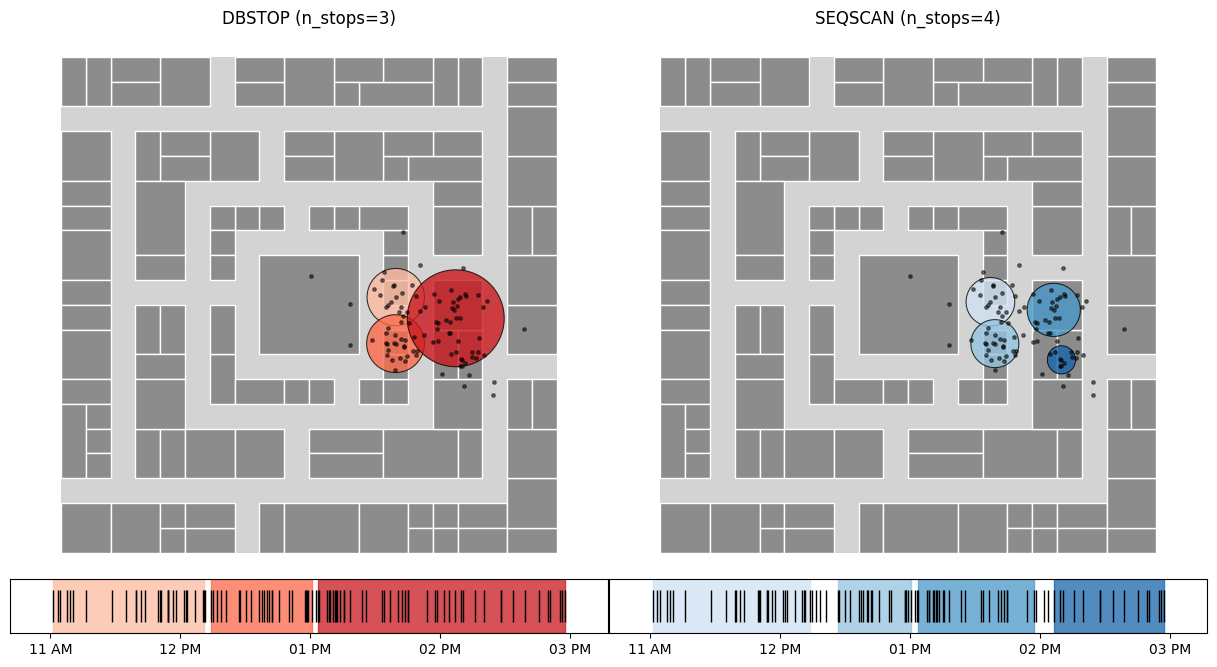

In [11]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 6.5),
    gridspec_kw={'height_ratios': [10, 1]},
)

plot_specs = [
    (algo_a, stops_a, axes[0, 0], axes[1, 0], 'Reds'),
    (algo_b, stops_b, axes[0, 1], axes[1, 1], 'Blues'),
]

for name, stops, ax_map, ax_barcode, cmap in plot_specs:
    gpd.GeoDataFrame(geometry=[outer_box], crs='EPSG:3857').plot(ax=ax_map, color='#d3d3d3')
    city.plot(ax=ax_map, edgecolor='white', linewidth=1, color='#8c8c8c')

    plot_stops(stops, ax=ax_map, cmap=cmap)
    plot_pings(traj, ax=ax_map, s=6, color='black', alpha=0.5, traj_cols=tc)
    ax_map.set_title(f'{name.upper()} (n_stops={len(stops)})')
    ax_map.set_axis_off()

    plot_time_barcode(traj['unix_ts'], ax=ax_barcode, set_xlim=True)
    plot_stops_barcode(stops, ax=ax_barcode, cmap=cmap, set_xlim=False, timestamp='unix_ts')

plt.tight_layout(pad=0.1)
plt.show()

In [12]:
def summarize_stops(name, stops):
    out = {'algorithm': name, 'n_stops': len(stops)}
    if len(stops) == 0:
        out.update({'start_min': None, 'end_max': None, 'median_duration_min': None})
        return out

    start_col = 'unix_ts' if 'unix_ts' in stops.columns else 'start_timestamp'
    end_col = 'end_timestamp' if 'end_timestamp' in stops.columns else start_col

    out.update({
        'start_min': int(stops[start_col].min()),
        'end_max': int(stops[end_col].max()),
        'median_duration_min': float(stops['duration'].median()) if 'duration' in stops.columns else None,
    })
    return out

summary_df = pd.DataFrame([
    summarize_stops(algo_a, stops_a),
    summarize_stops(algo_b, stops_b),
])
summary_df

,algorithm,n_stops,start_min,end_max,median_duration_min
0,dbstop,3,1704106881,1704121040,69.0
1,seqscan,4,1704106881,1704121040,51.5
